In [74]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import re

from sec_certs.dataset.common_criteria import CCDataset
from sec_certs.cert_rules import rules_crypto_algs

plt.style.use('seaborn')


In [2]:
dset = CCDataset.from_web_latest()
df = dset.to_pandas()

## Helper functions for preprocessing of cryptographic algorithms

In [130]:
aes_rule = rules_crypto_algs[3]
des_rule = rules_crypto_algs[12]
rsa_rule = rules_crypto_algs[0]

sha2_rule = rules_crypto_algs[2]
sha1_rule = rules_crypto_algs[4]
md5_rule = rules_crypto_algs[5]


def process_keywords(keywords_dict):
    keywords_dict = {x: (y['rules_crypto_algs'] if y else None) for x, y in keywords_dict.items()}
    return {x: y if y else None for x, y in keywords_dict.items()}

def process_crypto_df(dgst_date_df, keywords_dict):
    df_keywords = pd.Series(keywords_dict)
    df_keywords = pd.DataFrame({'crypto_algs': df_keywords})
    df_keywords.index.name = 'dgst'
    df_keywords = df_keywords.fillna(np.nan)

    df_keywords.loc[:, 'AES'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(aes_rule, x)) for x in x.keys()]))
    df_keywords.loc[:, 'DES'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(des_rule, x)) for x in x.keys()]))
    df_keywords.loc[:, 'RSA'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(rsa_rule, x)) for x in x.keys()]))

    df_keywords.loc[:, 'SHA2'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(sha2_rule, x)) for x in x.keys()]))
    df_keywords.loc[:, 'SHA1'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(sha1_rule, x)) for x in x.keys()]))
    df_keywords.loc[:, 'MD5'] = df_keywords.crypto_algs.map(lambda x: False if isinstance(x, float) else any([bool(re.match(md5_rule, x)) for x in x.keys()]))

    return pd.concat([dgst_date_df, df_keywords], axis='columns')

## Plot fraction of certificate reports containing AES / DES

In [131]:
report_keywords = process_keywords({x: dset[x].pdf_data.report_keywords for x in dset.certs})
st_keywords = process_keywords({x: dset[x].pdf_data.st_keywords for x in dset.certs})
df.loc[:, 'year_published'] = df.not_valid_before.dt.year
dgst_date_df = df.loc[:, 'year_published']

reports_df = process_crypto_df(dgst_date_df, report_keywords)
st_df = process_crypto_df(dgst_date_df, st_keywords)

<ipython-input-132-02a97ff698d6>:8: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


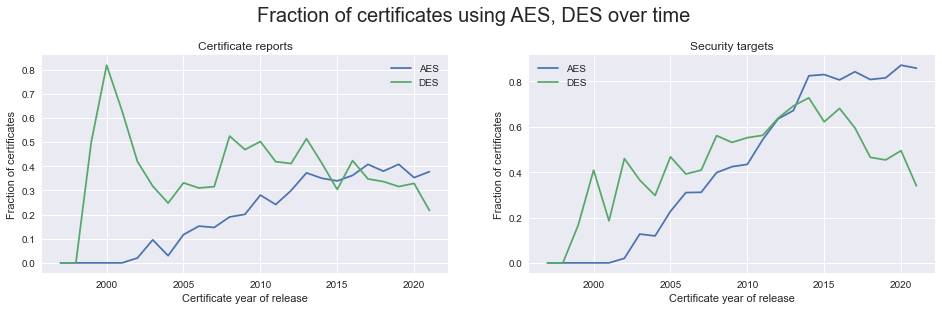

In [132]:
aes_des_reports = reports_df.groupby('year_published')[['AES', 'DES']].mean()
aes_des_st = st_df.groupby('year_published')[['AES', 'DES']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
fig.suptitle('Fraction of certificates using AES, DES over time', size=20, y=1.05)
aes_des_reports.plot.line(ax=ax1, title='Certificate reports', xlabel='Certificate year of release', ylabel='Fraction of certificates')
aes_des_st.plot.line(ax=ax2, title='Security targets', xlabel='Certificate year of release', ylabel='Fraction of certificates')
fig.show()

<ipython-input-133-bd5806bc0454>:8: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


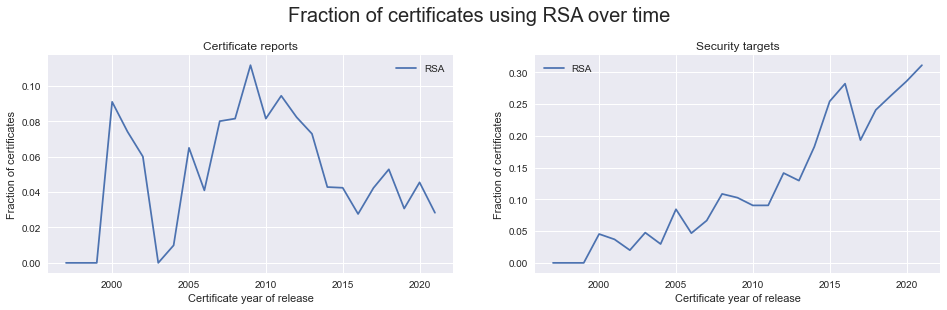

In [133]:
rsa_reports = reports_df.groupby('year_published')[['RSA']].mean()
rsa_st = st_df.groupby('year_published')[['RSA']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
fig.suptitle('Fraction of certificates using RSA over time', size=20, y=1.05)
rsa_reports.plot.line(ax=ax1, title='Certificate reports', xlabel='Certificate year of release', ylabel='Fraction of certificates')
rsa_st.plot.line(ax=ax2, title='Security targets', xlabel='Certificate year of release', ylabel='Fraction of certificates')
fig.show()

<ipython-input-134-8b83f41ee260>:8: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


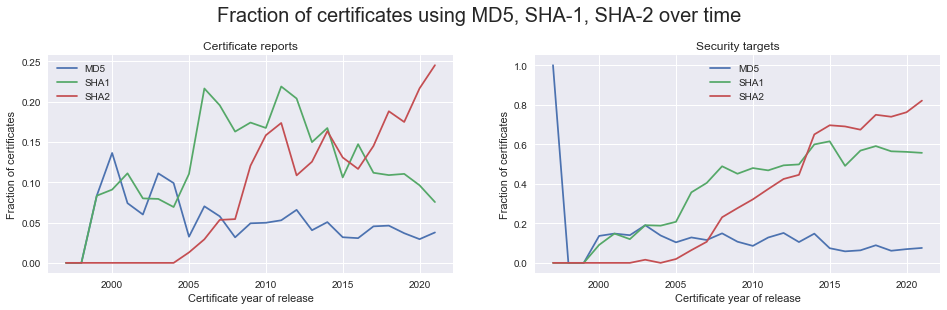

In [134]:
hash_reports = reports_df.groupby('year_published')[['MD5', 'SHA1', 'SHA2']].mean()
hash_st = st_df.groupby('year_published')[['MD5', 'SHA1', 'SHA2']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
fig.suptitle('Fraction of certificates using MD5, SHA-1, SHA-2 over time', size=20, y=1.05)
hash_reports.plot.line(ax=ax1, title='Certificate reports', xlabel='Certificate year of release', ylabel='Fraction of certificates')
hash_st.plot.line(ax=ax2, title='Security targets', xlabel='Certificate year of release', ylabel='Fraction of certificates')
fig.show()